# Notebook 1: Explanatory Data Analysis (EDA) for End-to-end satellite image classification using CNN: A case study using EuroSat RGB dataset

A CNN Portfolio from Yonathan Hary Hutagalung

# Introduction

Land use and land cover (LULC) monitoring is a cornerstone of environmental planning, renewable energy siting, and sustainable development policy. Satellite imagery from the European Space Agency's Sentinel-2 mission provides freely accessible, high-resolution optical data that makes large-scale land surface monitoring possible at a fraction of the cost of traditional field surveys.

This project applies Convolutional Neural Network (CNN)-based deep learning to automatically classify land cover types from RGB satellite tiles using the EuroSAT dataset — a benchmark of 27,000 labeled Sentinel-2 images spanning 10 distinct land cover classes across Europe. By fine-tuning pretrained CNN architectures through the Hugging Face Transformers ecosystem, this work demonstrates how modern deep learning pipelines can be applied to real-world geospatial classification challenges.

# Project Scope

This project covers the full machine learning pipeline for satellite image classification: from exploratory data analysis (EDA) and data preprocessing, to model training, evaluation, and explainability. Three CNN architectures — ResNet-18, EfficientNet-B0, and Vision Transformer (ViT-Base) — are benchmarked against each other to identify the best-performing model for this task. All experiments are conducted in Google Colab using the Hugging Face datasets, transformers, and evaluate libraries.

The scope is intentionally end-to-end: it begins with understanding the data's spectral and spatial properties, progresses through model fine-tuning, and concludes with interpretability analysis using GradCAM visualizations and a publicly accessible Gradio demo deployed on Hugging Face Spaces. The project does not extend to multispectral (non-RGB) bands, object detection, or time-series change detection, which are identified as natural next steps.

#Evaluation Metrics

Model performance is evaluated using a held-out validation set comprising 20% of the training data (5,400 samples), stratified by class. The primary metric is overall accuracy, which measures the proportion of correctly classified tiles and allows direct comparison with the EuroSAT benchmark paper (Helber et al., 2019). To capture per-class performance, macro-averaged F1 score, precision, and recall are also reported for all 10 classes.

Beyond scalar metrics, a confusion matrix is generated to visually identify the most frequent misclassifications between similar land cover types — for example, "Highway" vs. "Industrial" or "Forest" vs. "Pasture." Model interpretability is further evaluated through GradCAM (Gradient-weighted Class Activation Mapping), which highlights the spatial regions within each tile that most influenced the model's prediction, providing a layer of explainability critical for scientific and policy applications.

# 0. Library Importing

In [ ]:
!pip -q install datasets transformers matplotlib seaborn scikit-learn Pillow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset
from collections import Counter
from PIL import Image, ImageStat
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# 1. Dataset Loading

In [ ]:
dataset = load_dataset("blanchon/EuroSAT_RGB")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 16200
    })
    test: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
    validation: Dataset({
        features: ['image', 'label', 'filename'],
        num_rows: 5400
    })
})


In [ ]:
labels = dataset["train"].features["label"].names
id2label = {i: lbl for i, lbl in enumerate(labels)}
label2id = {lbl: i for i, lbl in enumerate(labels)}

print(f" Number of classes: {len(labels)}")
print(f" Classes: {labels}")
print(f" Total train samples: {len(dataset['train'])}")

 Number of classes: 10
 Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
 Total train samples: 16200


# 2. Class Distribution

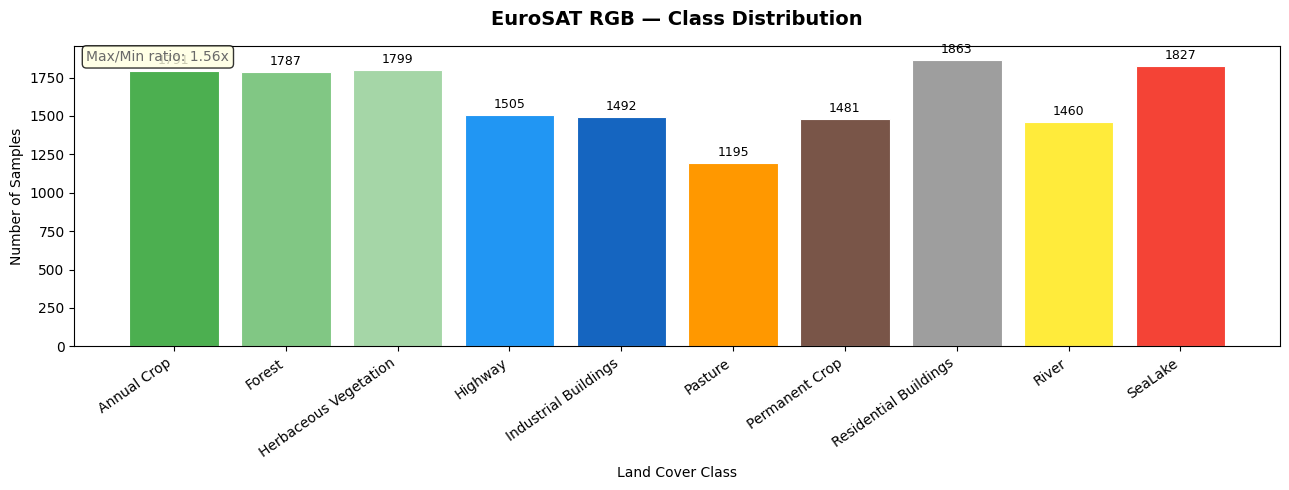

                Class  Count
          Annual Crop   1791
               Forest   1787
Herbaceous Vegetation   1799
              Highway   1505
 Industrial Buildings   1492
              Pasture   1195
       Permanent Crop   1481
Residential Buildings   1863
                River   1460
              SeaLake   1827


In [ ]:
label_counts = Counter(dataset["train"]["label"])
counts = [label_counts[i] for i in range(len(labels))]
df_dist = pd.DataFrame({"Class": labels, "Count": counts})

# Sustainability color palette: greens for nature, browns for urban
colors = ["#4CAF50","#81C784","#A5D6A7","#2196F3","#1565C0",
          "#FF9800","#795548","#9E9E9E","#FFEB3B","#F44336"]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(df_dist["Class"], df_dist["Count"], color=colors, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_title("EuroSAT RGB — Class Distribution", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Land Cover Class"); ax.set_ylabel("Number of Samples")
ax.set_xticklabels(df_dist["Class"], rotation=35, ha="right")

max_c, min_c = max(counts), min(counts)
ax.annotate(f"Max/Min ratio: {max_c/min_c:.2f}x",
            xy=(0.01, 0.95), xycoords="axes fraction",
            fontsize=10, color="dimgray",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.savefig("eda_01_class_distribution.png", dpi=150)
plt.show()
print(df_dist.to_string(index=False))

# 3. Sample Grid per Class

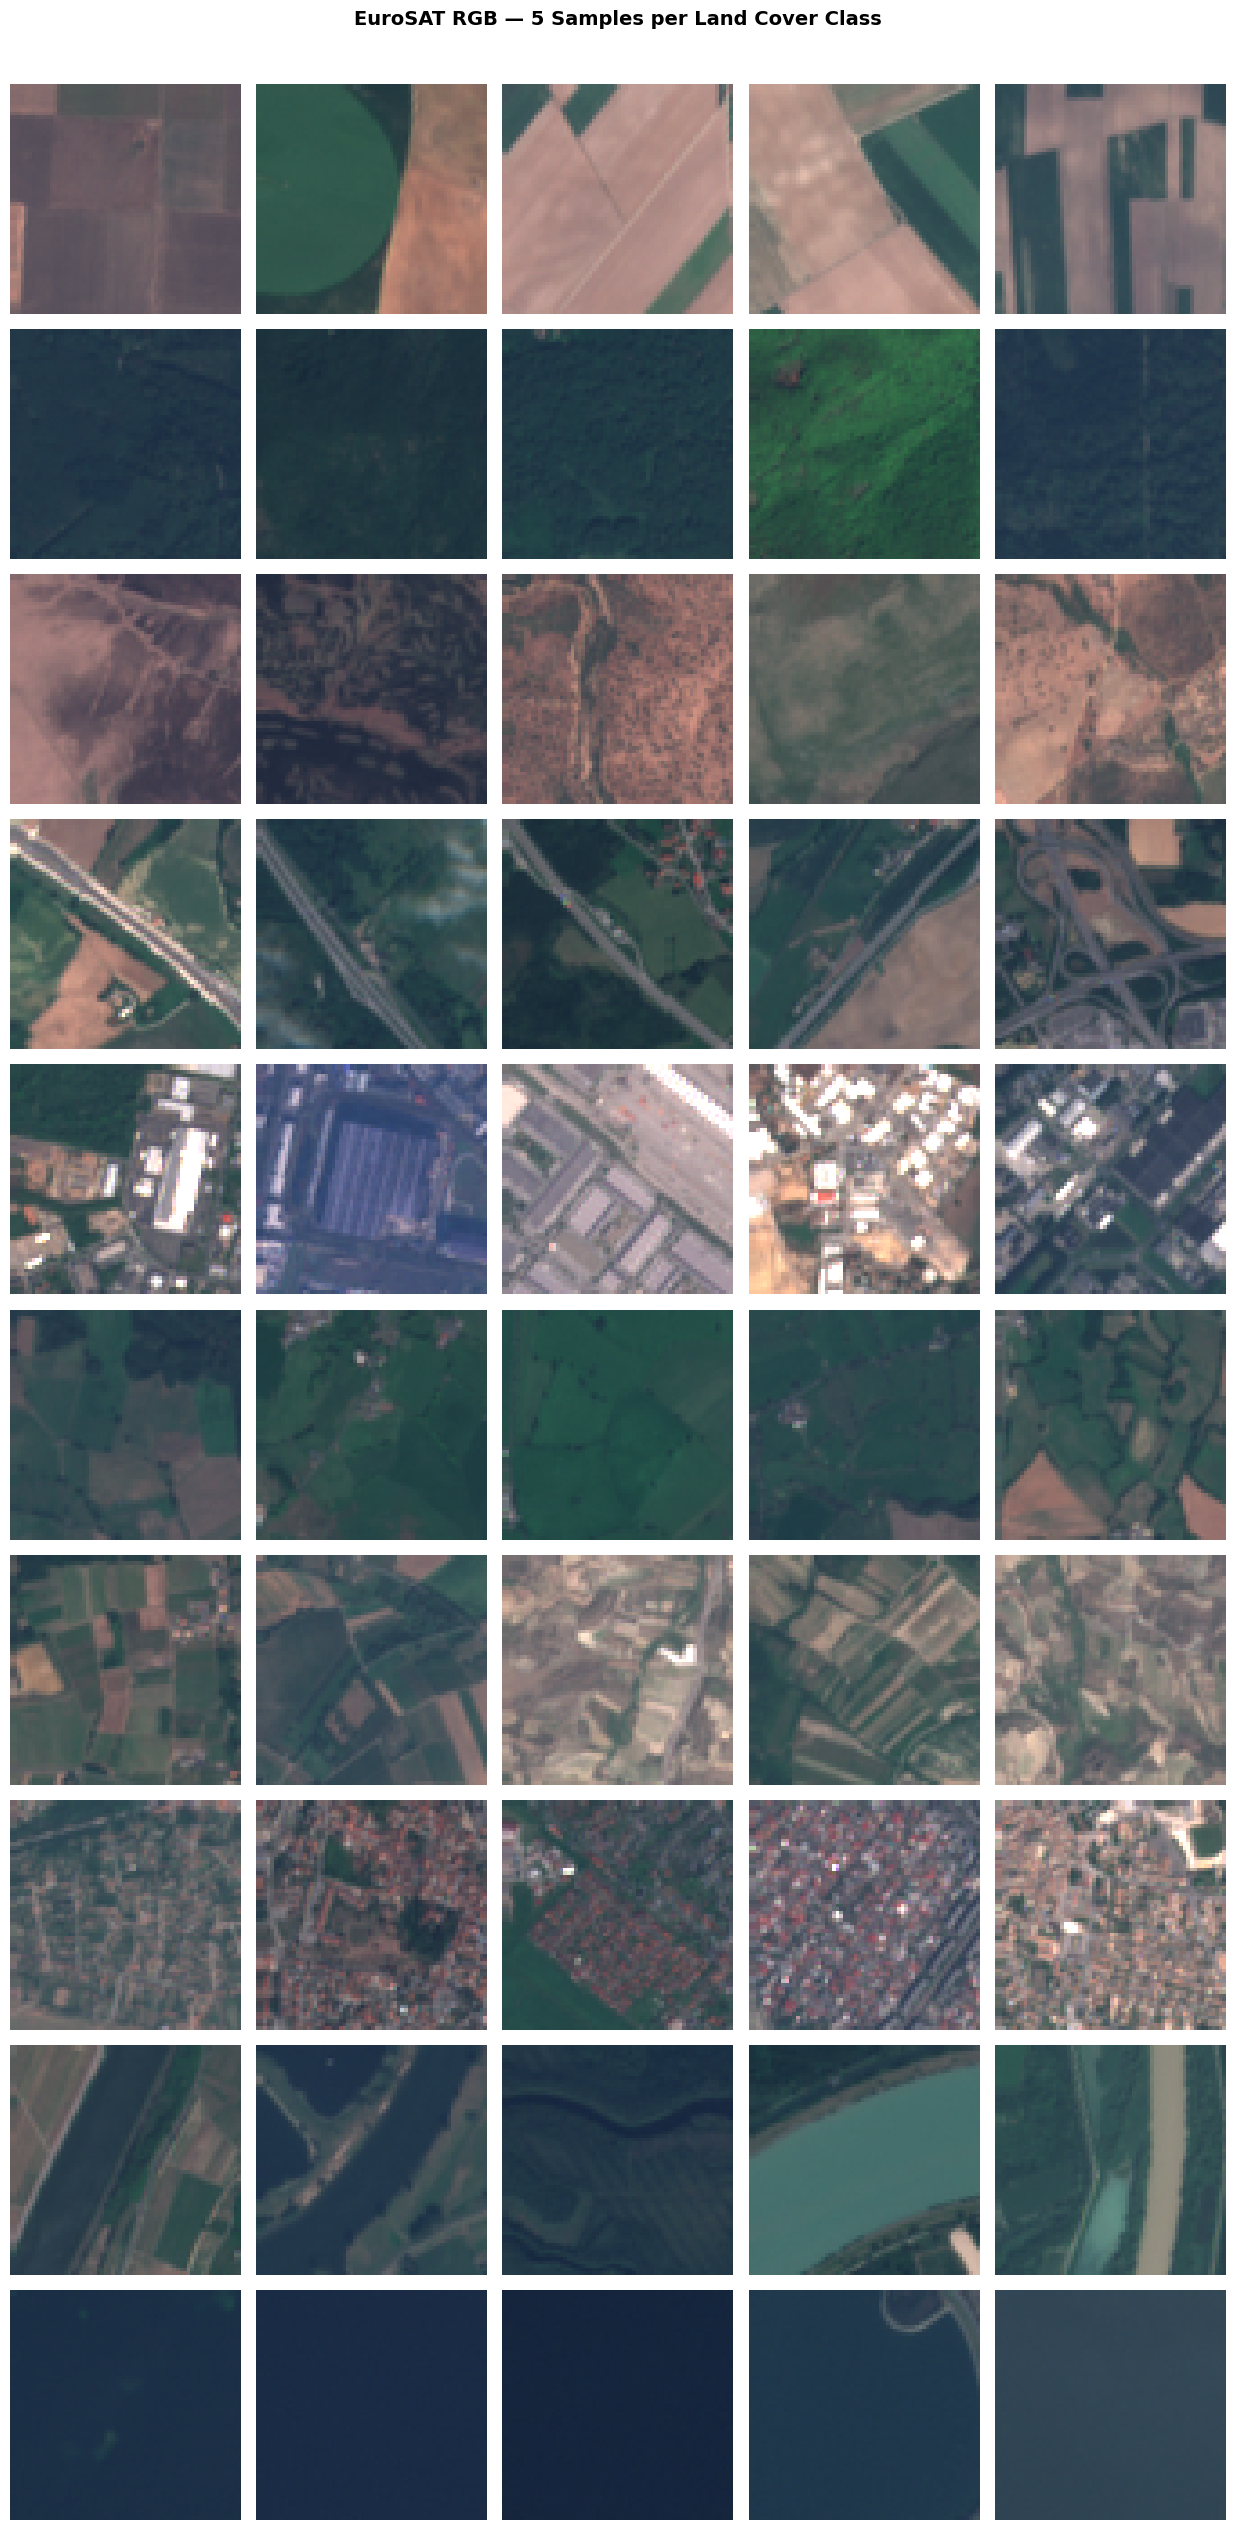

In [ ]:
n_samples = 5
fig, axes = plt.subplots(len(labels), n_samples, figsize=(n_samples*2.5, len(labels)*2.5))

for class_idx, class_name in enumerate(labels):
    class_samples = [x for x in dataset["train"] if x["label"] == class_idx][:n_samples]
    for col, sample in enumerate(class_samples):
        axes[class_idx][col].imshow(sample["image"])
        axes[class_idx][col].axis("off")
        if col == 0:
            axes[class_idx][col].set_ylabel(class_name, fontsize=9,
                                             rotation=0, labelpad=70,
                                             va="center", ha="right", fontweight="bold")

fig.suptitle("EuroSAT RGB — 5 Samples per Land Cover Class", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. Image size and Verification

In [ ]:
shapes = set()
for sample in dataset["train"].select(range(500)):
    shapes.add(np.array(sample["image"]).shape)

print(f"Unique image shapes found: {shapes}")

sample_img = np.array(dataset["train"][0]["image"])
print(f"\nDtype        : {sample_img.dtype}")
print(f"Shape        : {sample_img.shape}")
print(f"Pixel range  : [{sample_img.min()} – {sample_img.max()}]")
print(f"GSD          : ~10 meters per pixel (Sentinel-2)")
print(f"Tile coverage: {64 * 10 / 1000:.2f} km x {64 * 10 / 1000:.2f} km per tile")

Unique image shapes found: {(64, 64, 3)}

Dtype        : uint8
Shape        : (64, 64, 3)
Pixel range  : [75 – 195]
GSD          : ~10 meters per pixel (Sentinel-2)
Tile coverage: 0.64 km x 0.64 km per tile


# 5. RGB Channel per class

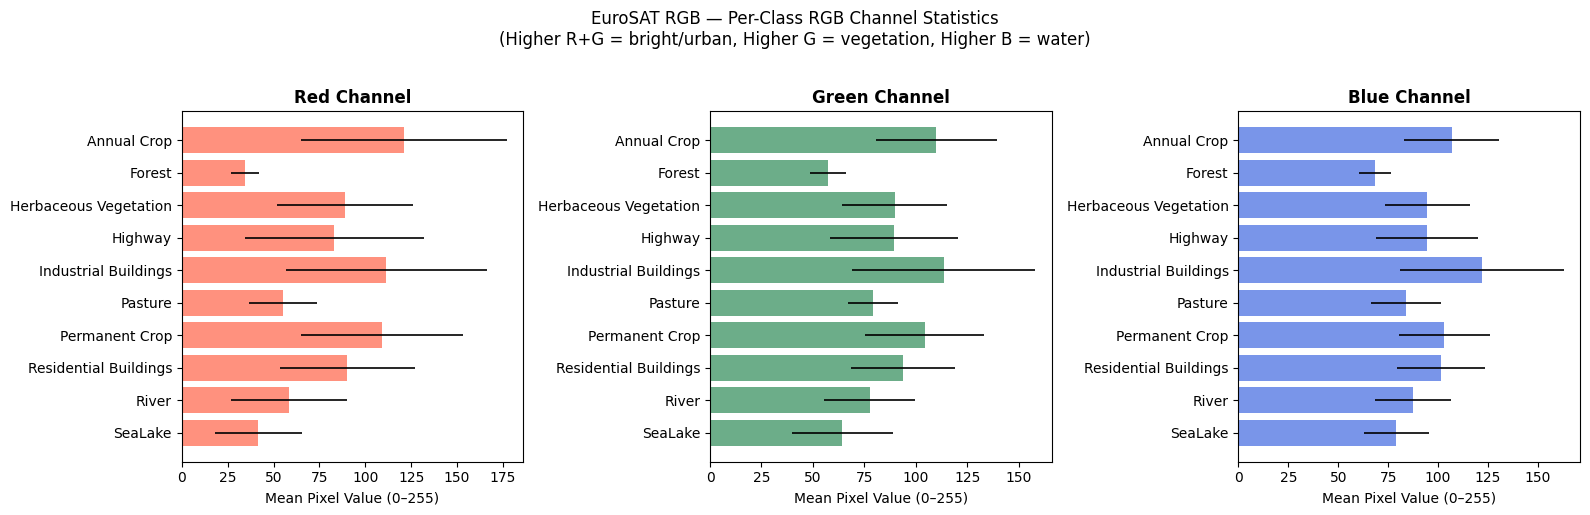

                           R_mean      G_mean      B_mean
Class                                                    
Annual Crop            121.199997  110.099998  106.699997
Forest                  34.500000   57.500000   68.500000
Herbaceous Vegetation   88.800003   89.699997   94.599998
Highway                 83.199997   89.599998   94.699997
Industrial Buildings   111.400002  113.599998  122.000000
Pasture                 55.299999   79.300003   83.900002
Permanent Crop         109.199997  104.500000  103.099998
Residential Buildings   90.300003   93.699997  101.400002
River                   58.500000   77.699997   87.500000
SeaLake                 41.700001   64.300003   79.099998


In [ ]:
n_per_class = 200
channel_stats = []

for class_idx, class_name in enumerate(labels):
    class_samples = [x for x in dataset["train"] if x["label"] == class_idx][:n_per_class]
    imgs = np.stack([np.array(s["image"]).astype(np.float32) for s in class_samples])
    channel_stats.append({
        "Class": class_name,
        "R_mean": imgs[:,:,:,0].mean(), "R_std": imgs[:,:,:,0].std(),
        "G_mean": imgs[:,:,:,1].mean(), "G_std": imgs[:,:,:,1].std(),
        "B_mean": imgs[:,:,:,2].mean(), "B_std": imgs[:,:,:,2].std(),
    })

df_stats = pd.DataFrame(channel_stats).set_index("Class")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
channels = [("R_mean", "R_std", "tomato", "Red Channel"),
            ("G_mean", "G_std", "seagreen", "Green Channel"),
            ("B_mean", "B_std", "royalblue", "Blue Channel")]

for ax, (mean_col, std_col, color, title) in zip(axes, channels):
    ax.barh(df_stats.index, df_stats[mean_col], xerr=df_stats[std_col],
            color=color, alpha=0.7, error_kw={"elinewidth": 1.2})
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Mean Pixel Value (0–255)")
    ax.invert_yaxis()

plt.suptitle("EuroSAT RGB — Per-Class RGB Channel Statistics\n"
             "(Higher R+G = bright/urban, Higher G = vegetation, Higher B = water)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print(df_stats[["R_mean","G_mean","B_mean"]].round(1).to_string())

# 6. RGB Histogram per-class

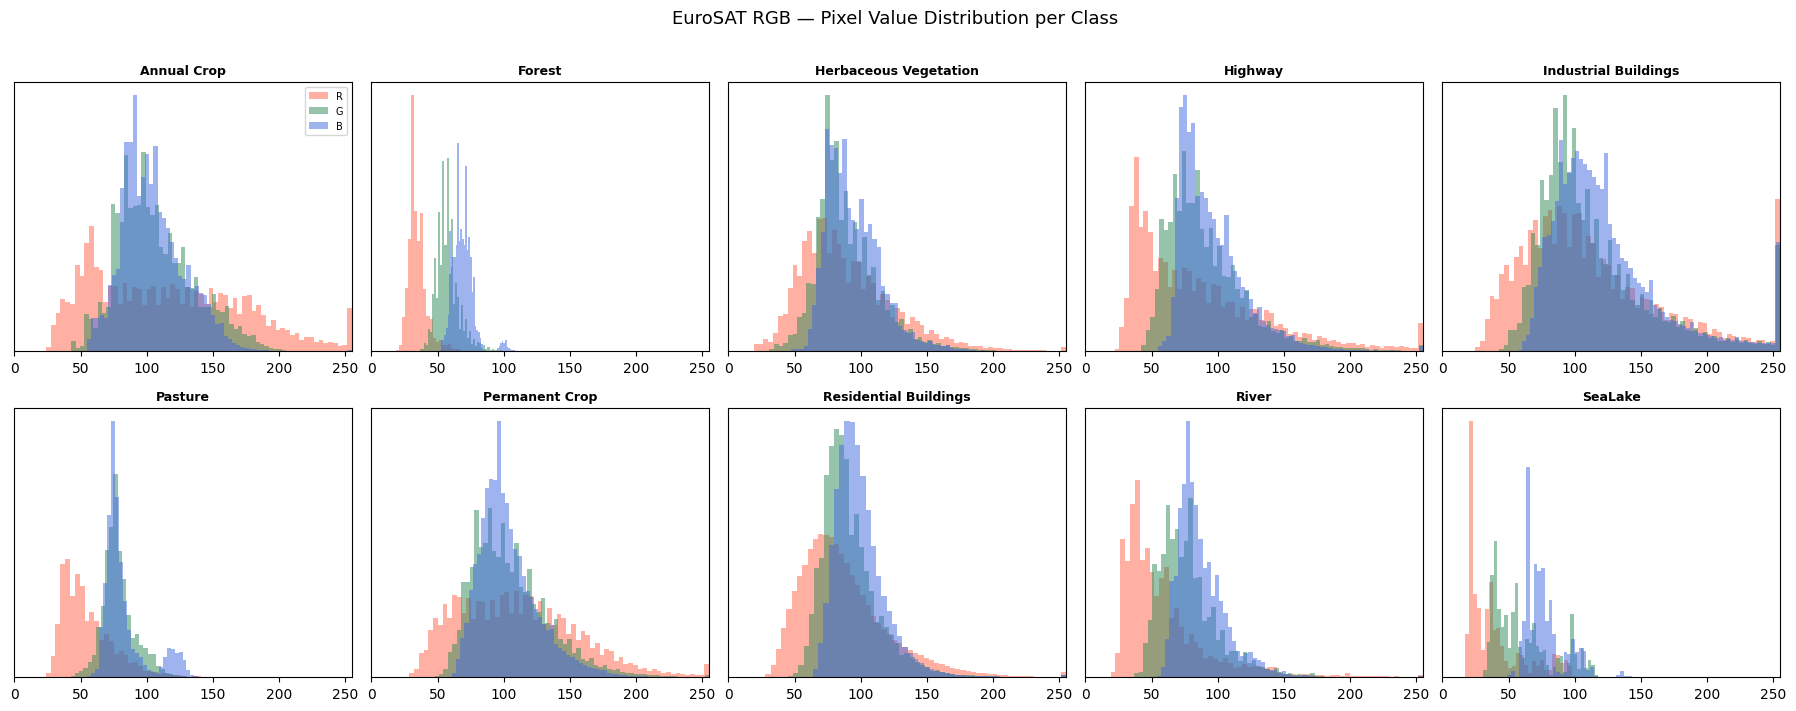

In [ ]:
n_per_class = 100
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for ax, (class_idx, class_name) in zip(axes.flat, enumerate(labels)):
    class_samples = [x for x in dataset["train"] if x["label"] == class_idx][:n_per_class]
    imgs = np.stack([np.array(s["image"]) for s in class_samples])

    for ch, (ch_name, color) in enumerate(zip(["R","G","B"], ["tomato","seagreen","royalblue"])):
        ax.hist(imgs[:,:,:,ch].flatten(), bins=64, alpha=0.5,
                color=color, label=ch_name, density=True)

    ax.set_title(class_name, fontsize=9, fontweight="bold")
    ax.set_xlim(0, 255); ax.set_yticks([])
    if class_idx == 0:
        ax.legend(fontsize=7)

plt.suptitle("EuroSAT RGB — Pixel Value Distribution per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 7. Brightness and Contrast per class

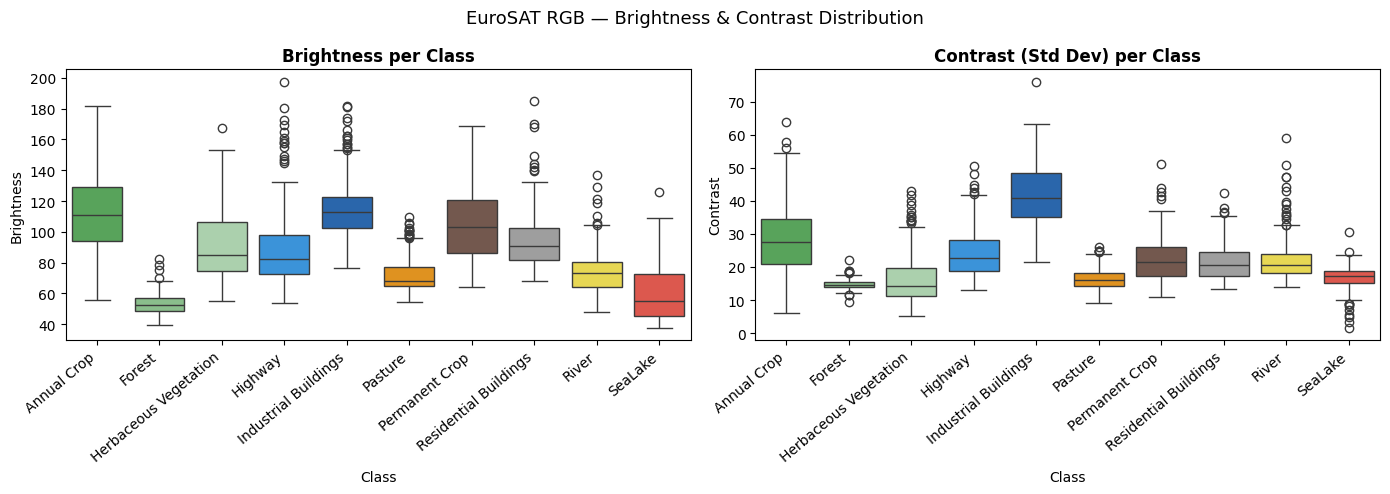

In [ ]:
n_per_class = 200
brightness_data = []

for class_idx, class_name in enumerate(labels):
    class_samples = [x for x in dataset["train"] if x["label"] == class_idx][:n_per_class]
    for s in class_samples:
        img_arr = np.array(s["image"]).astype(np.float32)
        brightness_data.append({
            "Class": class_name,
            "Brightness": img_arr.mean(),
            "Contrast": img_arr.std()
        })

df_bright = pd.DataFrame(brightness_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_bright, x="Class", y="Brightness",
            order=labels, ax=axes[0], palette=colors)
axes[0].set_title("Brightness per Class", fontweight="bold")
axes[0].set_xticklabels(labels, rotation=40, ha="right")

sns.boxplot(data=df_bright, x="Class", y="Contrast",
            order=labels, ax=axes[1], palette=colors)
axes[1].set_title("Contrast (Std Dev) per Class", fontweight="bold")
axes[1].set_xticklabels(labels, rotation=40, ha="right")

plt.suptitle("EuroSAT RGB — Brightness & Contrast Distribution", fontsize=13)
plt.tight_layout()
plt.show()

# 8. Class Similarity Heatmap (Mean RGB Distance)

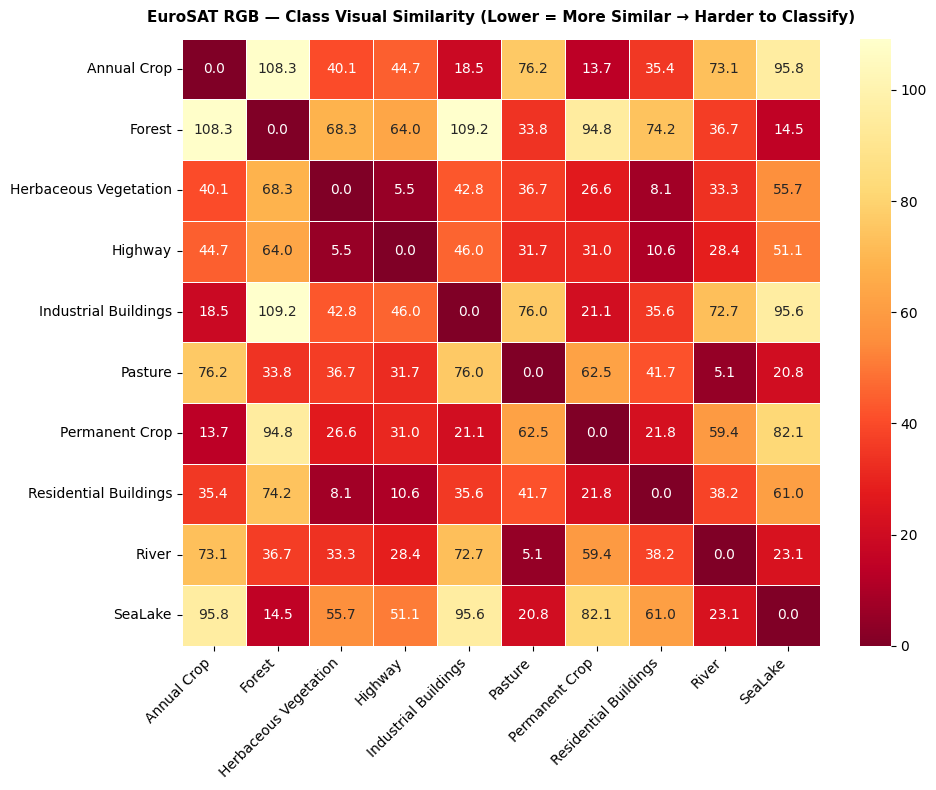

In [ ]:
import itertools

mean_rgb = {}
n = 200
for class_idx, class_name in enumerate(labels):
    samples = [x for x in dataset["train"] if x["label"] == class_idx][:n]
    imgs = np.stack([np.array(s["image"]).astype(np.float32) for s in samples])
    mean_rgb[class_name] = imgs.mean(axis=(0,1,2))

dist_matrix = np.zeros((len(labels), len(labels)))
for i, ci in enumerate(labels):
    for j, cj in enumerate(labels):
        dist_matrix[i, j] = np.linalg.norm(mean_rgb[ci] - mean_rgb[cj])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dist_matrix, xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".1f", cmap="YlOrRd_r",
            linewidths=0.5, ax=ax)
ax.set_title("EuroSAT RGB — Class Visual Similarity (Lower = More Similar → Harder to Classify)",
             fontsize=11, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 9. EDA Summary Plot

In [ ]:
print("="*55)
print("  📊 EuroSAT RGB — EDA Summary Report")
print("="*55)
print(f"  Total samples   : {sum(counts):,}")
print(f"  Number of classes: {len(labels)}")
print(f"  Image resolution : 64 × 64 px (RGB)")
print(f"  Ground resolution: ~10 m/px (Sentinel-2)")
print(f"  Tile coverage    : ~0.64 km × 0.64 km")
print(f"  Class balance    : Max/Min = {max(counts)}/{min(counts)} ({max(counts)/min(counts):.2f}x)")
print("-"*55)
print(f"{'Class':<22} {'Count':>7}  {'Share':>7}")
print("-"*55)
for lbl, cnt in zip(labels, counts):
    print(f"  {lbl:<20} {cnt:>7,}  {cnt/sum(counts)*100:>6.1f}%")
print("="*55)

  📊 EuroSAT RGB — EDA Summary Report
  Total samples   : 16,200
  Number of classes: 10
  Image resolution : 64 × 64 px (RGB)
  Ground resolution: ~10 m/px (Sentinel-2)
  Tile coverage    : ~0.64 km × 0.64 km
  Class balance    : Max/Min = 1863/1195 (1.56x)
-------------------------------------------------------
Class                    Count    Share
-------------------------------------------------------
  Annual Crop            1,791    11.1%
  Forest                 1,787    11.0%
  Herbaceous Vegetation   1,799    11.1%
  Highway                1,505     9.3%
  Industrial Buildings   1,492     9.2%
  Pasture                1,195     7.4%
  Permanent Crop         1,481     9.1%
  Residential Buildings   1,863    11.5%
  River                  1,460     9.0%
  SeaLake                1,827    11.3%
